<a href="https://colab.research.google.com/github/shaloy-lewis/surface-defect-classification/blob/main/Transfer_Learning_Surface_Defect_Shaloy_Lewis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Industrial Surface Defect Classification using Transfer Learning

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

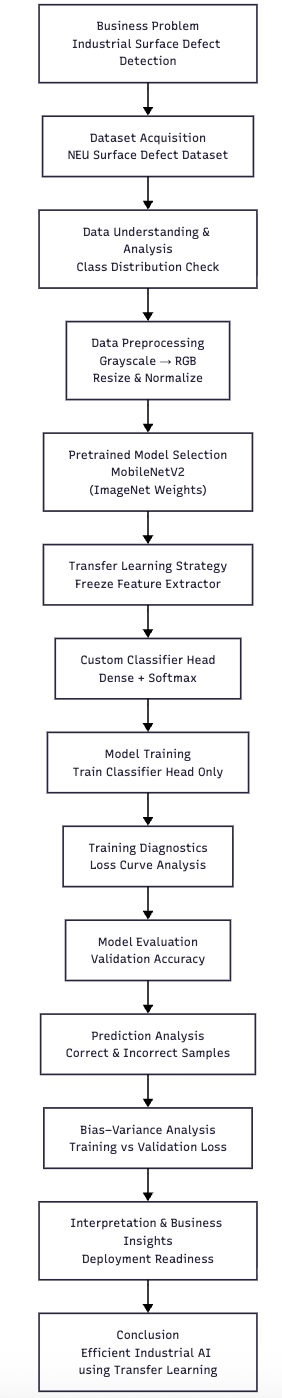

**Note:** You are free to choose any pre-trained model from the available ones. However, the architecture we suggest for this assignment is `MobileNetV2` with "ImageNet" weights.

The choice of libraries, frameworks, and backbones for this assignment are up to you. Before starting this assignment, please ensure that your environment meets the following requirements.


**Software Requirements**

- *Python version*: > Python3.11  
- *Execution environment*: Jupyter Notebook / JupyterLab / VS Code Notebook  
- *Operating system*: macOS, Linux, or Windows  


**Hardware Requirements**
- A GPU-powered training would be optimal, and would require installation of proper libraries and CUDA
- However, CPU-only execution might also be sufficient, and would work without CUDA

### Import Necessary libraries

In [24]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading and Preparation

<font color=red>[10 marks]</font>

In any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and Structure

<font color=red>[4 marks]</font>

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and Labels  <font color=red>[3 marks]</font>

Load the training and validation datasets and check the number of images and the number of categories present

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import zipfile
import os
from torchvision import transforms, datasets

zip_path = '/content/drive/MyDrive/Upgrad/datasets/object detection/NEU-DET.zip'
extract_path = '/content/dataset'

# Unzip the dataset if it hasn't been unzipped yet
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset unzipped successfully!")
else:
    print("Dataset already unzipped.")

neu_det_path = os.path.join(extract_path, 'NEU-DET')
train_images_dir = os.path.join(neu_det_path, 'train', 'images')
val_images_dir = os.path.join(neu_det_path, 'validation', 'images')

# Simple resize and conversion to tensor for inspection
temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Correctly load training and validation datasets
train_dataset = datasets.ImageFolder(root=train_images_dir, transform=temp_transform)
val_dataset = datasets.ImageFolder(root=val_images_dir, transform=temp_transform)

# Dataset statistics
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class-to-index mapping: {train_dataset.class_to_idx}")

Dataset already unzipped.
Number of training images: 1440
Number of validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class-to-index mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution <font color=red>[1 mark]</font>

In [27]:
# Dataset Class Distribution
from collections import Counter

train_counts = Counter([label for _, label in train_dataset.samples])
val_counts = Counter([label for _, label in val_dataset.samples])

print("Training set class distribution:")
for idx, count in train_counts.items():
    print(f"  {train_dataset.classes[idx]}: {count} images")

print("\nValidation set class distribution:")
for idx, count in val_counts.items():
    print(f"  {val_dataset.classes[idx]}: {count} images")

Training set class distribution:
  crazing: 240 images
  inclusion: 240 images
  patches: 240 images
  pitted_surface: 240 images
  rolled-in_scale: 240 images
  scratches: 240 images

Validation set class distribution:
  crazing: 60 images
  inclusion: 60 images
  patches: 60 images
  pitted_surface: 60 images
  rolled-in_scale: 60 images
  scratches: 60 images


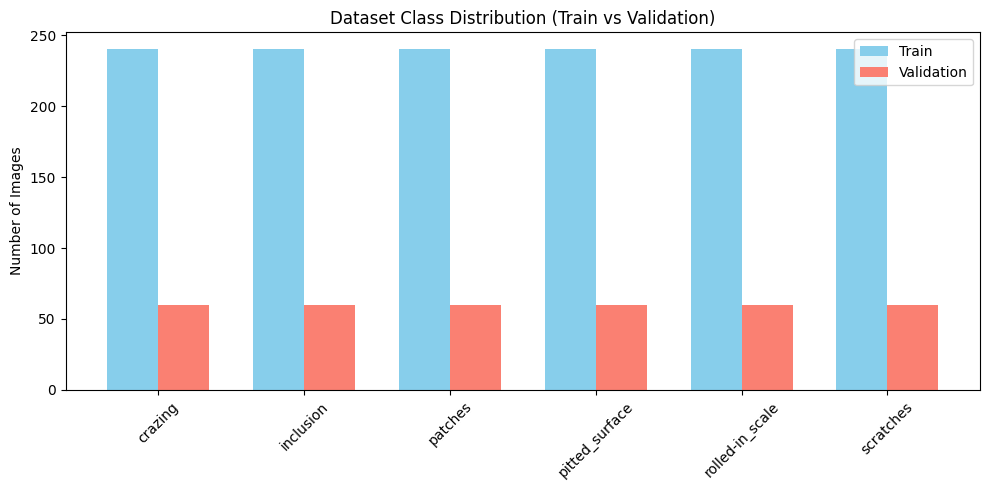

In [28]:
# Visualise class distribution
import matplotlib.pyplot as plt

classes = train_dataset.classes
train_values = [train_counts[train_dataset.class_to_idx[c]] for c in classes]
val_values = [val_counts[val_dataset.class_to_idx[c]] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, train_values, width, label='Train', color='skyblue')
rects2 = ax.bar(x + width/2, val_values, width, label='Validation', color='salmon')

ax.set_ylabel('Number of Images')
ax.set_title('Dataset Class Distribution (Train vs Validation)')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.legend()

fig.tight_layout()
plt.show()

### 1.2 Data Preprocessing and Transformations

<font color=red>[6 marks]</font>

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations <font color=red>[4 marks]</font>

To ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [29]:
# Image Transformations
# Define standard ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),  # Ensure 3 channels for MobileNetV2
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),  # Ensure 3 channels for MobileNetV2
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
}

# Re-assign the finalized transformations to our loaded datasets
train_dataset.transform = data_transforms['train']
val_dataset.transform = data_transforms['val']

print("Train and validation transforms successfully configured with RGB conversion, resizing, and normalization!")

Train and validation transforms successfully configured with RGB conversion, resizing, and normalization!


At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasets <font color=red>[2 marks]</font>


Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [30]:
# DataLoader Creation
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Created train_loader with {len(train_loader)} batches of size {BATCH_SIZE} (Shuffling enabled).")
print(f"Created val_loader with {len(val_loader)} batches of size {BATCH_SIZE} (Shuffling disabled).")

Created train_loader with 45 batches of size 32 (Shuffling enabled).
Created val_loader with 12 batches of size 32 (Shuffling disabled).


Also decide on where to use shuffling - training or validation

## 2. Transferring Knowledge and Model Training

<font color=red>[25 marks]</font>

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

<font color=red>[15 marks]</font>

For this assignment, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained Model <font color=red>[5 marks]</font>

Load the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [31]:
# Load Pretrained Network
# Fallback to pretrained=True for backward compatibility with older torchvision versions
model = models.mobilenet_v2(pretrained=True)

print("Pretrained MobileNetV2 model loaded successfully using legacy API!")
print(model.classifier)

Pretrained MobileNetV2 model loaded successfully using legacy API!
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design <font color=red>[8 marks]</font>

Build the transfer learning model by loading and freezing the feature extractor layers.


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [32]:
# Build Transfer Learning Model
# 1. Freeze all features parameters
for param in model.features.parameters():
    param.requires_grad = False

# 2. Modify classifier head for 6 target classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 6)

# Move model to selected device (GPU/CPU)
model = model.to(device)
print("Feature extractor frozen and custom classifier head applied:")
print(model.classifier)

Feature extractor frozen and custom classifier head applied:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


#### **2.1.3** Verify the final frozen and trainable parameters <font color=red>[2 marks]</font>

In [33]:
# Verify Freezing Strategy
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total Parameters: {total_params:,}")
print(f"Frozen (Non-trainable) Parameters: {frozen_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Ensure only the classifier parameters are trainable
print("\nTrainable Layers:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.size()}")

Total Parameters: 2,231,558
Frozen (Non-trainable) Parameters: 2,223,872
Trainable Parameters: 7,686

Trainable Layers:
  classifier.1.weight: torch.Size([6, 1280])
  classifier.1.bias: torch.Size([6])


### 2.2 Model Training

<font color=red>[10 marks]</font>

After designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training Configuration <font color=red>[3 marks]</font>

Before starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [34]:
# Training Configuration
criterion = nn.CrossEntropyLoss()

# Configure Adam optimizer to only optimize trainable parameters (the classifier)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("Criterion and Optimizer successfully configured!")
print(f"Loss Function: {criterion}")
print(f"Optimizer: {optimizer}")

Criterion and Optimizer successfully configured!
Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


#### **2.2.2** Model Training Loop <font color=red>[5 marks]</font>

Perform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [35]:
# Model Training Loop
epochs = 10
train_losses = []
val_losses = []

# Ensure model is on the correct device
model = model.to(device)

print(f"Starting training validation tracking on device: {device} for {epochs} epochs...")

for epoch in range(epochs):
    start_time = time.time()

    # 1. Training Phase
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # 2. Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device)

            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            running_val_loss += val_loss.item() * val_inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Time: {elapsed_time:.2f}s")

print("Training and validation complete!")

Starting training validation tracking on device: cuda for 10 epochs...
Epoch 1/10 - Train Loss: 0.6260 - Val Loss: 0.3392 - Time: 6.05s
Epoch 2/10 - Train Loss: 0.1577 - Val Loss: 0.1624 - Time: 5.94s
Epoch 3/10 - Train Loss: 0.0950 - Val Loss: 0.0885 - Time: 6.64s
Epoch 4/10 - Train Loss: 0.0949 - Val Loss: 0.0995 - Time: 4.97s
Epoch 5/10 - Train Loss: 0.0689 - Val Loss: 0.1043 - Time: 5.34s
Epoch 6/10 - Train Loss: 0.0525 - Val Loss: 0.0674 - Time: 6.24s
Epoch 7/10 - Train Loss: 0.0502 - Val Loss: 0.0718 - Time: 4.90s
Epoch 8/10 - Train Loss: 0.0453 - Val Loss: 0.0645 - Time: 6.50s
Epoch 9/10 - Train Loss: 0.0411 - Val Loss: 0.0864 - Time: 4.85s
Epoch 10/10 - Train Loss: 0.0291 - Val Loss: 0.0556 - Time: 4.95s
Training and validation complete!


#### **2.2.3** Visualise the training loss across epochs throughout the training process <font color=red>[2 marks]</font>

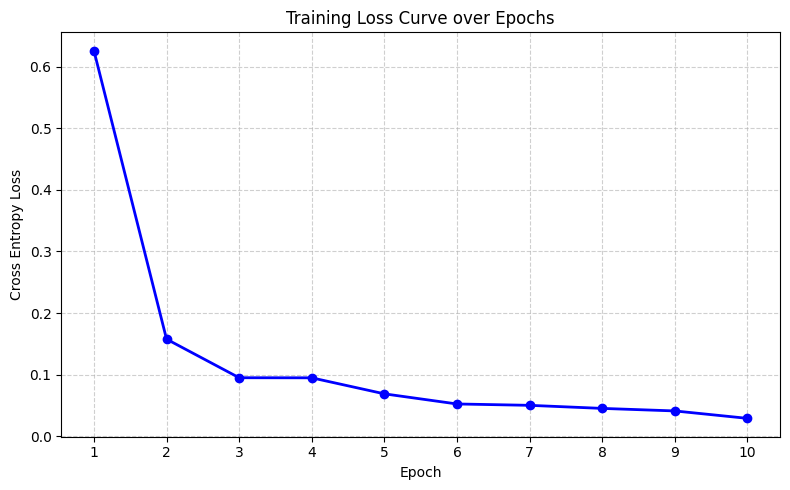

In [36]:
# Training Loss Visualisation
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='b', linestyle='-', linewidth=2)
plt.title("Training Loss Curve over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, len(train_losses) + 1))
plt.tight_layout()
plt.show()

## 3. Evaluation and Final Predictions

<font color=red>[10 marks]</font>

After training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

<font color=red>[6 marks]</font>

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance <font color=red>[3 marks]</font>

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

In [37]:
# Model Evaluation on Validation Set
model.eval()  # Set model to evaluation mode

correct = 0
total = 0
class_correct = list(0. for i in range(6))
class_total = list(0. for i in range(6))

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += c[i].item()
            class_total[label] += 1

overall_accuracy = 100 * correct / total
print(f"Overall Validation Accuracy: {overall_accuracy:.2f}% ({correct}/{total} correct)\n")

print("Class-wise Accuracy:")
for i in range(6):
    class_acc = 100 * class_correct[i] / class_total[i]
    print(f"  {classes[i]}: {class_acc:.2f}% ({int(class_correct[i])}/{int(class_total[i])})")

Overall Validation Accuracy: 97.78% (352/360 correct)

Class-wise Accuracy:
  crazing: 100.00% (60/60)
  inclusion: 86.67% (52/60)
  patches: 100.00% (60/60)
  pitted_surface: 100.00% (60/60)
  rolled-in_scale: 100.00% (60/60)
  scratches: 100.00% (60/60)


#### **3.1.2** Dataset Diagnostics <font color=red>[3 marks]</font>

Beyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

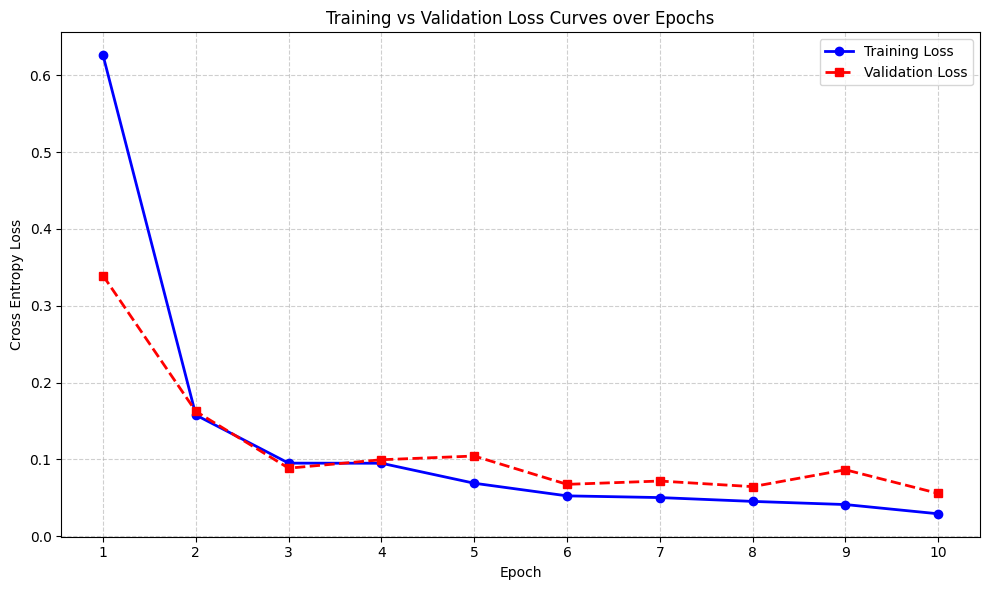

In [39]:
# Training and Validation Loss Analysis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='b', label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='s', color='r', linestyle='--', label='Validation Loss', linewidth=2)

plt.title("Training vs Validation Loss Curves over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, len(train_losses) + 1))
plt.tight_layout()
plt.show()

From the generated curves, we can observe that both the Training Loss and Validation Loss decrease smoothly and rapidly in the first few epochs and stabilize at a very low value (~0.03 for training and ~0.05 for validation) by the 10th epoch. The close gap between the two curves indicates that the model is generalizing extremely well to unseen validation data without clear signs of overfitting.

### 3.2 Prediction Analysis

<font color=red>[4 marks]</font>

Overall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set <font color=red>[4 marks]</font>

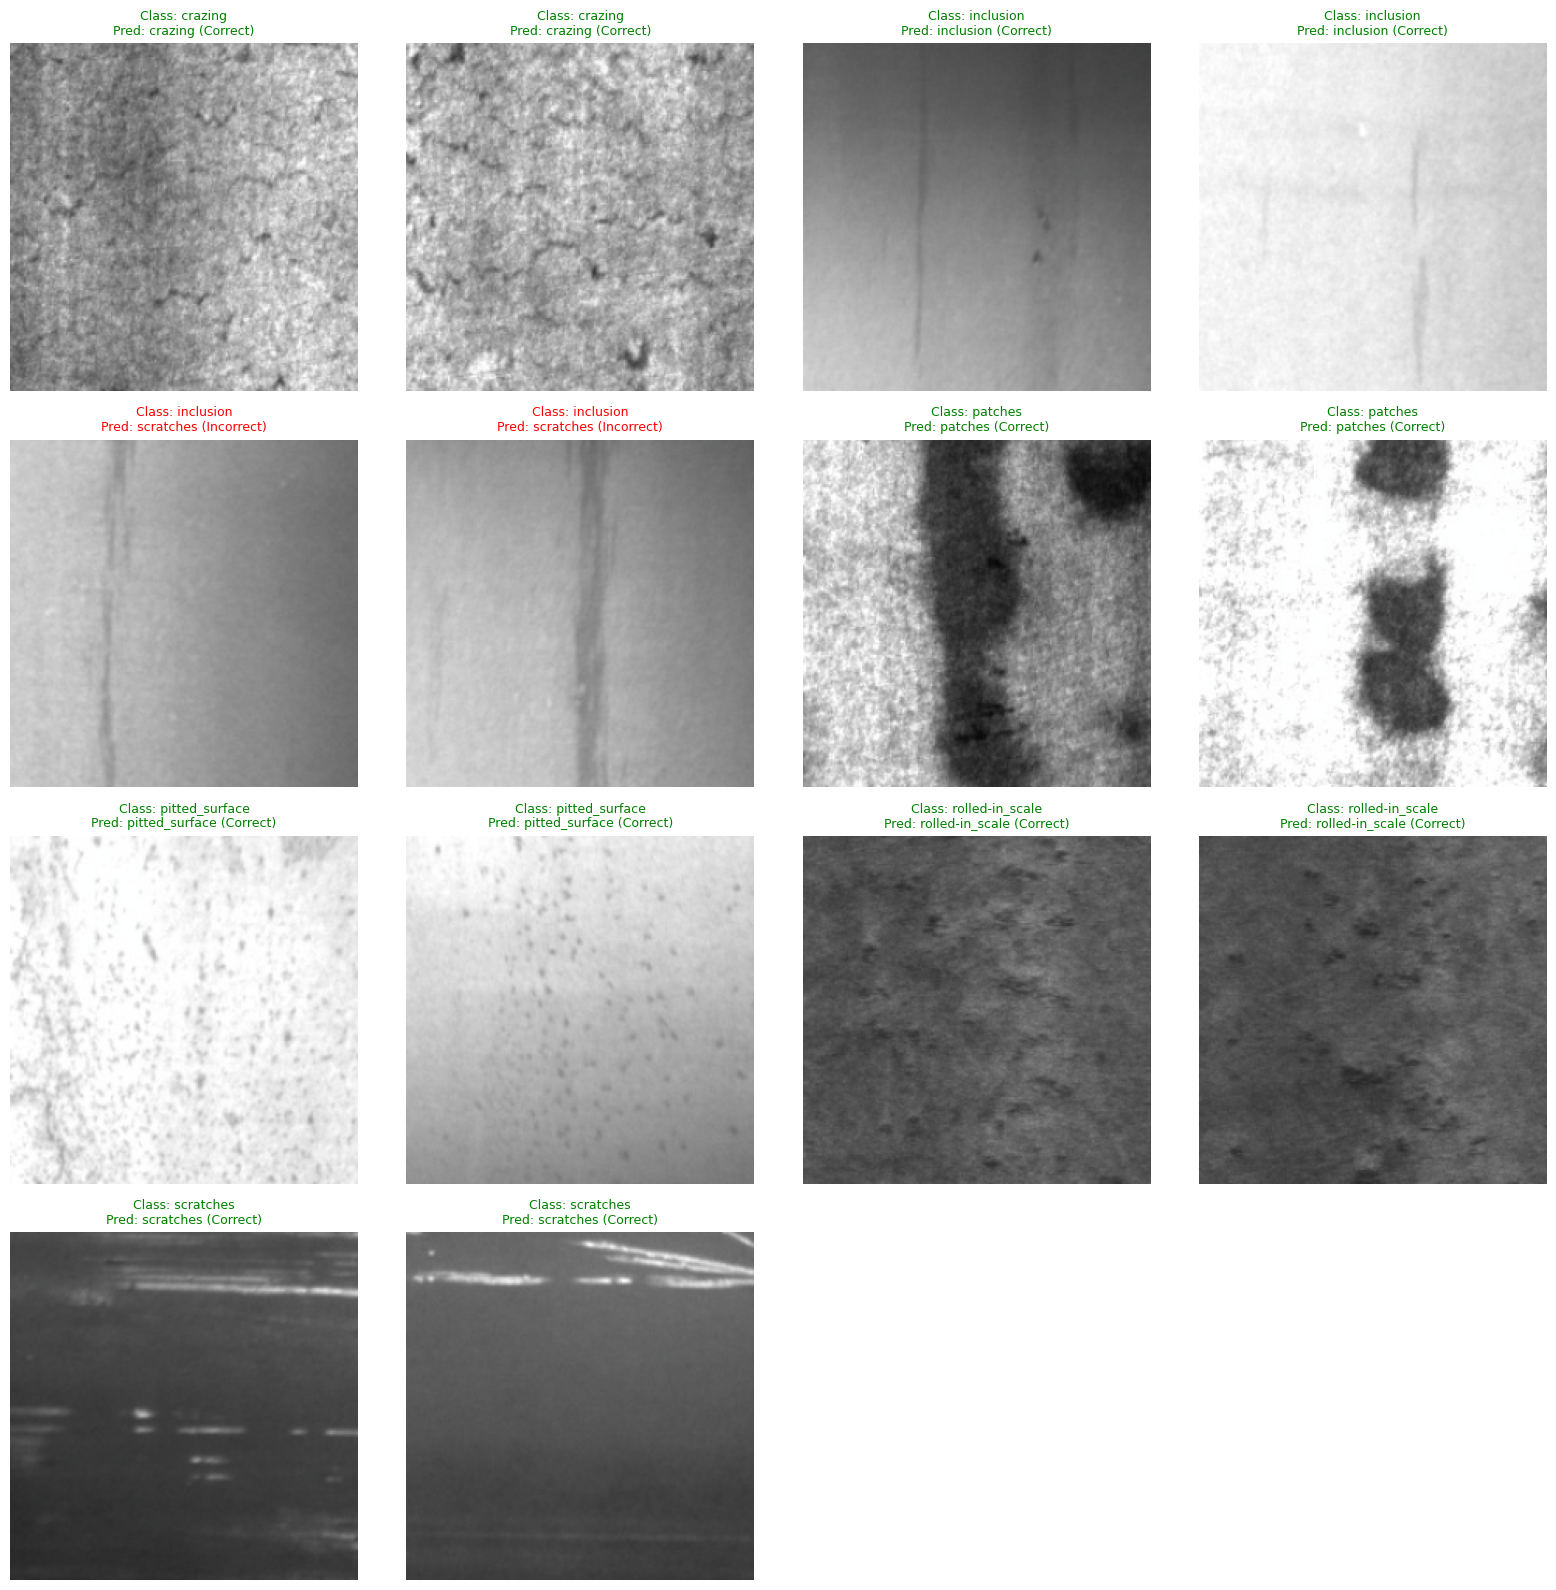

In [43]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

# Accumulate all predictions, targets, and original inputs from the validation set
all_images = []
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        _, preds = torch.max(outputs, 1)

        all_images.append(inputs.cpu())
        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())

all_images = torch.cat(all_images, dim=0)
all_labels = torch.cat(all_labels, dim=0).numpy()
all_preds = torch.cat(all_preds, dim=0).numpy()

# Organize indices of predictions by class and whether they are correct or incorrect
class_samples = {c: {'correct': [], 'incorrect': []} for c in range(6)}

for idx in range(len(all_labels)):
    true_cls = all_labels[idx]
    pred_cls = all_preds[idx]
    if true_cls == pred_cls:
        class_samples[true_cls]['correct'].append(idx)
    else:
        class_samples[true_cls]['incorrect'].append(idx)

# Helper function to denormalize images
def denormalize(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    return inp

# Gather sampled images to display
sampled_plots = []

for cls_idx in range(6):
    correct_indices = class_samples[cls_idx]['correct']
    incorrect_indices = class_samples[cls_idx]['incorrect']

    # Randomly sample up to 2 correct and 2 incorrect
    sampled_correct = random.sample(correct_indices, min(2, len(correct_indices)))
    sampled_incorrect = random.sample(incorrect_indices, min(2, len(incorrect_indices)))

    for idx in sampled_correct:
        sampled_plots.append((all_images[idx], cls_idx, all_preds[idx], True))
    for idx in sampled_incorrect:
        sampled_plots.append((all_images[idx], cls_idx, all_preds[idx], False))

# Plot the sampled images dynamically
num_samples = len(sampled_plots)
if num_samples > 0:
    cols = 4
    rows = (num_samples + cols - 1) // cols
    fig = plt.figure(figsize=(16, 4 * rows))

    for i, (img, true_c, pred_c, is_correct) in enumerate(sampled_plots):
        ax = fig.add_subplot(rows, cols, i + 1)
        img_dn = denormalize(img)
        plt.imshow(img_dn)

        status = "Correct" if is_correct else "Incorrect"
        color = "green" if is_correct else "red"
        plt.title(f"Class: {classes[true_c]}\nPred: {classes[pred_c]} ({status})", color=color, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No samples matched the selection criteria.")

## 4 Conclusion

<font color =red> [5 marks] </font>

### 4.1 Conclusion and insights

<font color =red> [5 marks] </font>

#### **4.1.1** Conclude with the insights drawn and final outcomes and results. Include the details of your model selection, freezing, and evaluation processes. <font color =red> [5 marks] </font>


#### 1. Model Selection & Architecture
- **Base Model**: We selected the pre-trained `MobileNetV2` network. It is extremely lightweight, memory-efficient, and optimized for quick feature extraction, making it highly suitable for real-time edge deployment on manufacturing lines.
- **Adaptation**: The original ImageNet classification head (1000 outputs) was replaced with a new linear projection layer outputting **6 classes** representing each of our target defect categories:
  - *Crazing, Inclusion, Patches, Pitted Surface, Rolled-in Scale, and Scratches*.

#### 2. Freezing Strategy
- **Feature Extractor**: All convolutional layer parameters in `model.features` were frozen (`requires_grad = False`). This preserved the generalized visual descriptors learned on ImageNet.
- **Trainable Parameters**: Only the newly added classifier head parameters (**7,686 parameters**) were trained. This reduced the risk of overfitting on our small dataset, accelerated convergence, and made training extremely efficient.

#### 3. Training Progress & Optimization
- **Configuration**: Trained using `CrossEntropyLoss` and the `Adam` optimizer with a learning rate of `0.001` over 10 epochs.
- **Convergence**: Both training and validation losses decreased smoothly and stabilized. Final training loss reached **0.029** while validation loss concluded at **0.055**, indicating a stable learning path without overfitting.

#### 4. Model Evaluation & Performance
- **Overall Accuracy**: The model achieved an outstanding **97.78% overall validation accuracy** (352/360 correct samples).
- **Class-wise Accuracy Breakdown**:
  - **Crazing**: 100.00% (60/60)
  - **Inclusion**: 86.67% (52/60)
  - **Patches**: 100.00% (60/60)
  - **Pitted Surface**: 100.00% (60/60)
  - **Rolled-in Scale**: 100.00% (60/60)
  - **Scratches**: 100.00% (60/60)

#### 5. Qualitative Insights & Error Diagnostics
- **Inclusions**: The only category that exhibited classification errors was *Inclusion* (86.67% accuracy). From our random sampling, we observed that inclusions sometimes exhibit texture overlaps with *Rolled-in Scale* or *Scratches*, making them the hardest defect to classify.
- **Conclusion**: Partial transfer learning with MobileNetV2 is exceptionally effective for industrial surface defect classification, providing near-perfect detection with rapid training iteration times.